# Test background removal

## Remove background

In [1]:
from tools.utils import open_image
image_path = "/media/SSD_floricslimani/Fish_seq/Davide/2025-04-24 - HeLa R2TP_Run12/Location-10/img000_000_000000_0000000000.ome.tif"
image = open_image(image_path)
image = image[...,0]


In [2]:
#TODO : test background removal

image_back_rm = image.copy()


In [5]:
for idx, cycle in enumerate(image) :
    if idx >= len(image) : break
    elif idx %2 == 1 : continue
    image_back_rm[idx] = cycle - image_back_rm[idx + 1]

image_back_rm[image_back_rm < 0] = 0

print(image.shape)

(20, 66, 2004, 2004)


## Visualisation

In [4]:
import napari
import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

Viewer = napari.Viewer()
im_raw = Viewer.add_image(image, scale = (2,1,1))
im_bckrm = Viewer.add_image(image_back_rm, scale = (2,1,1))


## Blur Measure

In [12]:
import numpy as np
import bigfish.stack as stack
import matplotlib.pyplot as plt
from scipy.ndimage import laplace

In [29]:
im_laplacevar = np.stack([np.var(laplace(im)) for im in image])
imbckrm_laplacevar = np.stack([np.var(laplace(im)) for im in image_back_rm])

In [31]:
norm_im_laplacevar = []
norm_imbckrm_laplacevar = []

for i in range(len(im_laplacevar)) :
    if i >= len(im_laplacevar) : break
    elif i % 2 == 1 : continue
    
    norm_im_laplacevar.append((im_laplacevar[i] - im_laplacevar[i+1]) / im_laplacevar[i + 1])
    norm_imbckrm_laplacevar.append((imbckrm_laplacevar[i] - imbckrm_laplacevar[i+1]) / imbckrm_laplacevar[i + 1])

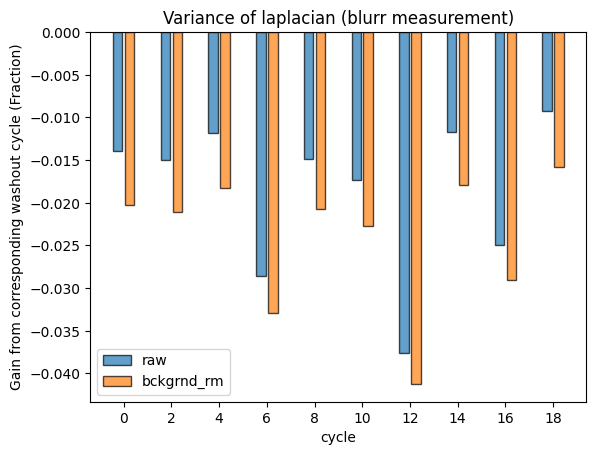

In [45]:
fig = plt.figure()
ax = fig.gca()

cycles = np.arange(len(norm_im_laplacevar)*2,step=2)

ax.bar(
    cycles -0.25, 
    norm_im_laplacevar,
    edgecolor = 'black',
    width=0.4,
    alpha= 0.7,
    label = "raw"
)
ax.bar(
    cycles +0.25, 
    norm_imbckrm_laplacevar,
    edgecolor = 'black',
    width=0.4,
    alpha= 0.7,
    label = "bckgrnd_rm"
    )

ax.legend()
ax.set_xticks(cycles, cycles)
ax.set_title("Variance of laplacian (blurr measurement)")
ax.set_ylabel("Gain from corresponding washout cycle (Fraction)")
ax.set_xlabel("cycle")
pass

Washout cycles are taken as reference for blurr measurement (var of laplacian) value shown  (is blur_meas - blur_meas_washout) / blur_meas_washout

## Elbow plot (bigfish)

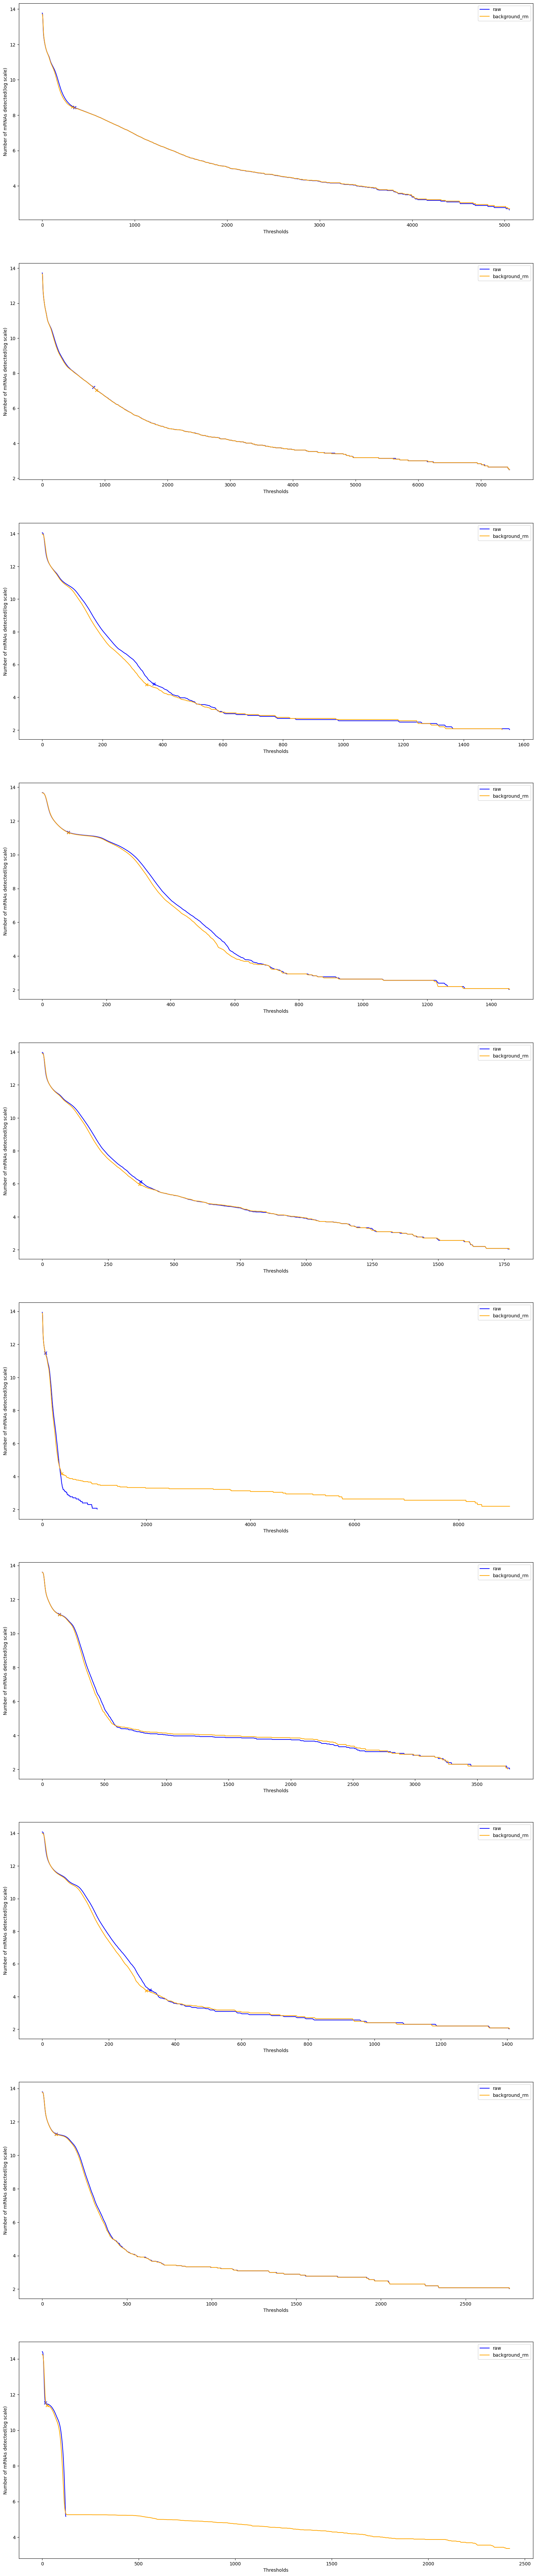

In [59]:
from bigfish.plot import plot_elbow
from bigfish.detection import get_elbow_values

VOXEL_SIZE = (200,97,97)
SPOT_SIZE = (300,200,200)

fig = plt.figure(figsize=(20,5* len(image)))
axes = fig.subplots(int(len(image) / 2),1)
axes = iter(axes)


for idx in range(len(image)) :

    if idx % 2 == 1 : continue

    ax : plt.axes = next(axes)

    for im, color, label in zip([image, image_back_rm], ['blue','orange'], ['raw', 'background_rm']) :
        thresholds_x, counts_y, crit_value = get_elbow_values(
            im[idx],
            spot_radius=SPOT_SIZE,
            voxel_size=VOXEL_SIZE,
        )
        ax.plot(thresholds_x, counts_y, color=color, label=label)
        
        i_threshold = np.argmax(thresholds_x == crit_value)
        ycrit = counts_y[i_threshold]
        ax.scatter(crit_value, ycrit, marker= 'x', color= color)

    ax.set_xlabel("Thresholds")
    ax.set_ylabel("Number of mRNAs detected(log scale)")
    ax.legend()
